Welcome to New York City, one of the most-visited cities in the world. There are many Airbnb listings in New York City to meet the high demand for temporary lodging for travelers, which can be anywhere between a few nights to many months. In this project, we will take a closer look at the New York Airbnb market by combining data from multiple file types like `.csv`, `.tsv`, and `.xlsx`.

Recall that **CSV**, **TSV**, and **Excel** files are three common formats for storing data. 
Three files containing data on 2019 Airbnb listings are available to you:

**data/airbnb_price.csv**
This is a CSV file containing data on Airbnb listing prices and locations.
- **`listing_id`**: unique identifier of listing
- **`price`**: nightly listing price in USD
- **`nbhood_full`**: name of borough and neighborhood where listing is located

**data/airbnb_room_type.xlsx**
This is an Excel file containing data on Airbnb listing descriptions and room types.
- **`listing_id`**: unique identifier of listing
- **`description`**: listing description
- **`room_type`**: Airbnb has three types of rooms: shared rooms, private rooms, and entire homes/apartments

**data/airbnb_last_review.tsv**
This is a TSV file containing data on Airbnb host names and review dates.
- **`listing_id`**: unique identifier of listing
- **`host_name`**: name of listing host
- **`last_review`**: date when the listing was last reviewed

**Objective:**
Analyze Airbnb listings in New York City to understand price patterns, popular room types, and host activity, while demonstrating data cleaning, validation, and exploratory data analysis (EDA) skills.

**Main Steps:**
- Load and combine multiple data formats (CSV, Excel, TSV)
- Validate and clean the data
- Explore key insights: prices, reviews, and hosts
- Visualize trends and relationships

## **1. Import Libraries and Load Dataset**

In [10]:
# Import necessary packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

#Read the TSV file (tab-separated file)
price = pd.read_csv("dataset/data_airbnb/airbnb_price.csv")

#Read the TSV file (tab-separated file)
room_type = pd.read_excel("dataset/data_airbnb/airbnb_room_type.xlsx")

#Read the TSV file (tab-separated file)
last_review = pd.read_csv("dataset/data_airbnb/airbnb_last_review.tsv", sep="\t")


**Preview each dataset**

In [14]:
display(price.head(), room_type.head(10), last_review.head())

,listing_id,price,nbhood_full
0,2595,225 dollars,"Manhattan, Midtown"
1,3831,89 dollars,"Brooklyn, Clinton Hill"
2,5099,200 dollars,"Manhattan, Murray Hill"
3,5178,79 dollars,"Manhattan, Hell's Kitchen"
4,5238,150 dollars,"Manhattan, Chinatown"


,listing_id,description,room_type
0,2595,Skylit Midtown Castle,Entire home/apt
1,3831,Cozy Entire Floor of Brownstone,Entire home/apt
2,5099,Large Cozy 1 BR Apartment In Midtown East,Entire home/apt
3,5178,Large Furnished Room Near B'way,private room
4,5238,Cute & Cozy Lower East Side 1 bdrm,Entire home/apt
5,5295,Beautiful 1br on Upper West Side,Entire home/apt
6,5441,Central Manhattan/near Broadway,Private room
7,5803,"Lovely Room 1, Garden, Best Area, Legal rental",Private room
8,6021,Wonderful Guest Bedroom in Manhattan for SINGLES,Private room
9,6848,Only 2 stops to Manhattan studio,entire home/apt


,listing_id,host_name,last_review
0,2595,Jennifer,May 21 2019
1,3831,LisaRoxanne,July 05 2019
2,5099,Chris,June 22 2019
3,5178,Shunichi,June 24 2019
4,5238,Ben,June 09 2019


## **2. Explore the structure of each dataset & Data Validation:**
This helps confirm:
- Number of rows and columns
- Data types (e.g., object, float64, datetime64)
- Whether there are missing values

In [12]:
print(price.info(), "\n")
print(room_type.info(), "\n")
print(last_review.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   price        25209 non-null  object
 2   nbhood_full  25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   description  25199 non-null  object
 2   room_type    25209 non-null  object
dtypes: int64(1), object(2)
memory usage: 591.0+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   host_name    25201 n

Analyse the result:
- The dataset has 25,209 rows.
- The DataFrame has 3 columns.
- No `non-null` data.
- However:
    - The description column has 25,199 valid entries.
        - That means 25,209 - 25,199 = 10 rows are missing a description (NaN).
    - 25,201 rows have a valid host name.
        - 8 rows are missing (25209 - 25201 = 8) host names.

- `price` column is stored as text : e.g., 225 dollars
- `room_type` capitalization varies : e.g., 'private room' vs 'Private room'

In [15]:
print("=== Missing Values Check ===")
print("Price Data:\n", price.isna().sum(), "\n")
print("Room Type Data:\n", room_type.isna().sum(), "\n")
print("Last Review Data:\n", last_review.isna().sum(), "\n")

=== Missing Values Check ===
Price Data:
 listing_id     0
price          0
nbhood_full    0
dtype: int64 

Room Type Data:
 listing_id      0
description    10
room_type       0
dtype: int64 

Last Review Data:
 listing_id     0
host_name      8
last_review    0
dtype: int64 



Meaning:
- No missing values in airbnb_price → clean dataset.
- In airbnb_room_type:
    - 10 missing description values → some listings don’t have text descriptions.
- In airbnb_last_review:
    - 8 missing host_name values → a few listings don’t have host names.
So, your data is almost perfectly clean — only minor missing text fields.

Fill the missing values:
- It won’t cause errors or major impact on your main analysis because the missing field is just the text, not the number.
- We may see some “NaN” values if you print or export.
- We can tidy up the dataset to make it look cleaner when exporting or visualizing.

In [16]:
# Replace missing descriptions and host names with "Unknown"
room_type['description'].fillna('No description available', inplace=True)
last_review['host_name'].fillna('Unknown', inplace=True)

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1479665941.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  room_type['description'].fillna('No description available', inplace=True)
C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1479665941.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [17]:
print("=== Duplicate ID Check ===")
print("Price duplicates:", price['listing_id'].duplicated().sum())
print("Room type duplicates:", room_type['listing_id'].duplicated().sum())
print("Last review duplicates:", last_review['listing_id'].duplicated().sum())

=== Duplicate ID Check ===
Price duplicates: 0
Room type duplicates: 0
Last review duplicates: 0


There are **no duplicate listing IDs** in any dataset.
It means every Airbnb listing appears only once in each dataset, so we can safely merge them later without worrying about duplicate rows.

In [18]:
print("=== ID Alignment Check ===")
ids_price = set(price['listing_id'])
ids_room = set(room_type['listing_id'])
ids_review = set(last_review['listing_id'])

print("IDs in all three datasets:", len(ids_price & ids_room & ids_review))
print("Only in price data:", len(ids_price - ids_room - ids_review))
print("Only in room type data:", len(ids_room - ids_price - ids_review))
print("Only in review data:", len(ids_review - ids_price - ids_room))

=== ID Alignment Check ===
IDs in all three datasets: 25209
Only in price data: 0
Only in room type data: 0
Only in review data: 0


**All three datasets contain exactly the same listings** (same 25,209 unique listing_id values).
That means every Airbnb listing has:
- a price,
- a room type, and
- a review record.
Perfect alignment — merging the data will be clean and consistent.

## **3. Merging the three DataFrames**

In [19]:
# Merge price and room type data
airbnb_merged = pd.merge(price, room_type, on='listing_id')

# Merge the result with the last review data
airbnb_merged = pd.merge(airbnb_merged, last_review, on='listing_id')

# Take a look at the result
airbnb_merged.head()

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt,Jennifer,May 21 2019
1,3831,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt,LisaRoxanne,July 05 2019
2,5099,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt,Chris,June 22 2019
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,June 24 2019
4,5238,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt,Ben,June 09 2019


## **4. Data Cleaning**
1. Convert `last_review` from string to datetime type
2. Standardized `room_type` column >> make all room types lowercase and strip whitespace
3. Clean `price` column >> convert the string value '225 dollars' to int value `225`

1. Convert `last_review` from string to datetime type

In [20]:
# Convert the 'last_review' column to datetime
airbnb_merged["last_review"] = pd.to_datetime(airbnb_merged["last_review"])

# Take a look at the result
airbnb_merged.head()

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt,Jennifer,2019-05-21
1,3831,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt,LisaRoxanne,2019-07-05
2,5099,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt,Chris,2019-06-22
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,2019-06-24
4,5238,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt,Ben,2019-06-09


In [23]:
# Find the earliest and most recent review dates
earliest_review = airbnb_merged["last_review"].min()
latest_review = airbnb_merged["last_review"].max()

print("Earliest review date:", earliest_review)
print("Most recent review date:", latest_review)

Earliest review date: 2019-01-01 00:00:00
Most recent review date: 2019-07-09 00:00:00


2. Standardized `room_type` column

In [24]:
# Clean capitalization in the room_type column
airbnb_merged['room_type'] = airbnb_merged['room_type'].str.lower().str.strip()

- `str.lower()` → converts all text to lowercase ("Private Room" → "private room").
- `str.strip()` → removes any leading or trailing spaces (in case of data entry errors).

In [25]:
# Count the number of listings for each room type
room_type_counts = airbnb_merged['room_type'].value_counts()
print("Room type counts:\n", room_type_counts)

# Get the number of private rooms specifically
private_room_count = (airbnb_merged['room_type'] == 'private room').sum()
print("\nNumber of private rooms:", private_room_count)

Room type counts:
 room_type
entire home/apt    13266
private room       11356
shared room          587
Name: count, dtype: int64

Number of private rooms: 11356


`value_counts()` → gives you a frequency table of all room types.

3. Clean `price` column

`replace('[\ dollars]', '', regex=True)`
→ Removes any 'dollars' string in price strings using a regular expression.
Example: "225 dollars" → "225"

`astype(float)`
→ Converts cleaned strings to numeric floats, allowing math operations.

`mean()`
→ Computes the average value of all numeric entries in the price column.

In [27]:
# Clean the 'price' column by removing '$' and ',' and convert it to float
airbnb_merged['price'] = (
    airbnb_merged['price']
    .replace('[\ dollars]', '', regex=True)   # remove $ and ,
    .astype(float)                      # convert to float
)

airbnb_merged.head(10)

,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225.0,"Manhattan, Midtown",Skylit Midtown Castle,entire home/apt,Jennifer,2019-05-21
1,3831,89.0,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,entire home/apt,LisaRoxanne,2019-07-05
2,5099,200.0,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,entire home/apt,Chris,2019-06-22
3,5178,79.0,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,2019-06-24
4,5238,150.0,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,entire home/apt,Ben,2019-06-09
5,5295,135.0,"Manhattan, Upper West Side",Beautiful 1br on Upper West Side,entire home/apt,Lena,2019-06-22
6,5441,85.0,"Manhattan, Hell's Kitchen",Central Manhattan/near Broadway,private room,Kate,2019-06-23
7,5803,89.0,"Brooklyn, South Slope","Lovely Room 1, Garden, Best Area, Legal rental",private room,Laurie,2019-06-24
8,6021,85.0,"Manhattan, Upper West Side",Wonderful Guest Bedroom in Manhattan for SINGLES,private room,Claudio,2019-07-05
9,6848,140.0,"Brooklyn, Williamsburg",Only 2 stops to Manhattan studio,entire home/apt,Allen & Irina,2019-06-29


In [28]:
airbnb_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25209 entries, 0 to 25208
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   listing_id   25209 non-null  int64         
 1   price        25209 non-null  float64       
 2   nbhood_full  25209 non-null  object        
 3   description  25209 non-null  object        
 4   room_type    25209 non-null  object        
 5   host_name    25209 non-null  object        
 6   last_review  25209 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 1.3+ MB


In [29]:
# Calculate the average price of all listings
avg_price = airbnb_merged['price'].mean()

print("Average listing price (USD):", avg_price)

Average listing price (USD): 141.7779364512674


## **5. Quick Look at Price Distributions**

Text(0.5, 1.0, 'Price Histogram')

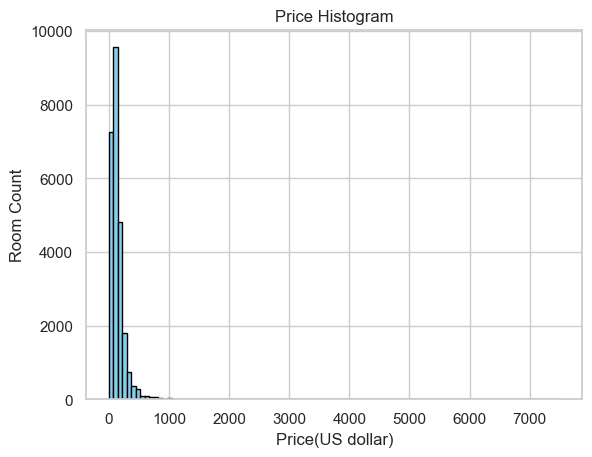

In [32]:
# Plotting a basic histogram
plt.hist(airbnb_merged['price'], bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Price(US dollar)')
plt.ylabel('Room Count')
plt.title('Price Histogram')

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\3332927894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb_merged, x='room_type', y='price', palette='Set2')


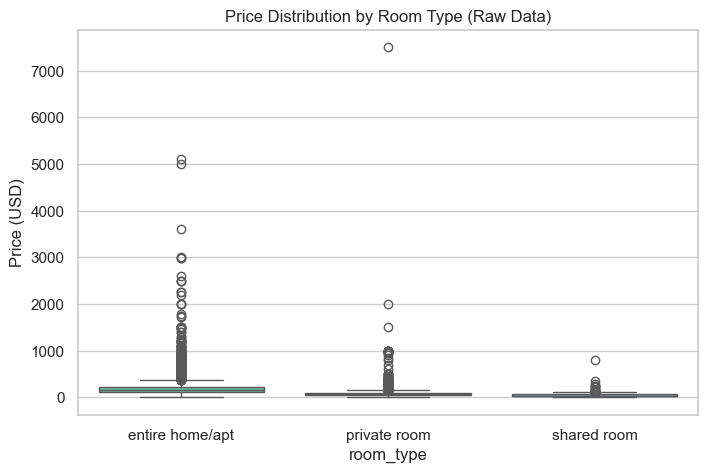

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=airbnb_merged, x='room_type', y='price', palette='Set2')
plt.title("Price Distribution by Room Type (Raw Data)")
plt.ylabel("Price (USD)")
plt.show()

In [34]:
# Find 10 lowest price
airbnb_merged[['price', 'nbhood_full', 'room_type']].sort_values('price', ascending=True).head(10)

,price,nbhood_full,room_type
10861,0.0,"Bronx, East Morrisania",private room
10958,0.0,"Brooklyn, Bushwick",private room
11577,0.0,"Brooklyn, Bushwick",shared room
11589,0.0,"Brooklyn, Bushwick",shared room
11024,0.0,"Brooklyn, Bedford-Stuyvesant",private room
11025,0.0,"Brooklyn, Bedford-Stuyvesant",private room
11023,0.0,"Brooklyn, Bedford-Stuyvesant",private room
24806,10.0,"Brooklyn, Bushwick",private room
16643,10.0,"Brooklyn, Bedford-Stuyvesant",entire home/apt
12135,10.0,"Brooklyn, Greenpoint",entire home/apt


In [36]:
# Find 10 highest price
airbnb_merged[['price', 'nbhood_full', 'room_type']].sort_values('price', ascending=False).head(10)

,price,nbhood_full,room_type
23916,7500.0,"Brooklyn, East Flatbush",private room
22085,5100.0,"Manhattan, Midtown",entire home/apt
18430,5000.0,"Manhattan, Harlem",entire home/apt
21731,3613.0,"Manhattan, Upper West Side",entire home/apt
12508,3000.0,"Manhattan, SoHo",entire home/apt
24432,2995.0,"Manhattan, Chelsea",entire home/apt
13528,2990.0,"Manhattan, Nolita",entire home/apt
21838,2600.0,"Queens, Bayside",entire home/apt
1234,2500.0,"Manhattan, East Village",entire home/apt
23601,2500.0,"Brooklyn, Crown Heights",entire home/apt


Observation:
- The price isn't reasonable, since there are some room which cost only 0 US dollar per night which there are some room where the price up to 7500 US dollar.
- These prices can be errors or outliers in this dataset, can come from missing data (for 0$ room) or typos (for 7500$)
- These outliers distort averages and make visualizations misleading

## 6. Outlier Detection and Cleaning
Some listings had unrealistic prices (e.g., $0 or over $7000), which could distort analysis.  
To fix this, I used the **Interquartile Range (IQR)** method to detect and remove outliers.

- **IQR** = Q3 − Q1 (the range of the middle 50% of data)
- Outliers are values below Q1 − 3×IQR or above Q3 + 3×IQR  
- Applied **per room type** to respect natural price differences between shared rooms, private rooms, and entire homes.

In [39]:
def remove_outliers_iqr(group, k=3):
    Q1, Q3 = group['price'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - k*IQR, Q3 + k*IQR
    return group[(group['price'] >= lower) & (group['price'] <= upper)]

airbnb_clean = airbnb_merged.groupby('room_type', group_keys=False).apply(remove_outliers_iqr, k=3)

print(f"Original rows: {len(airbnb_merged)}, After cleaning: {len(airbnb_clean)}")

Original rows: 25209, After cleaning: 24636


C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\2852472270.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  airbnb_clean = airbnb_merged.groupby('room_type', group_keys=False).apply(remove_outliers_iqr, k=3)


Compare before and after:

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1781390573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb_merged, x='room_type', y='price', ax=axes[0], palette='Set2')
C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\1781390573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=airbnb_clean, x='room_type', y='price', ax=axes[1], palette='Set2')


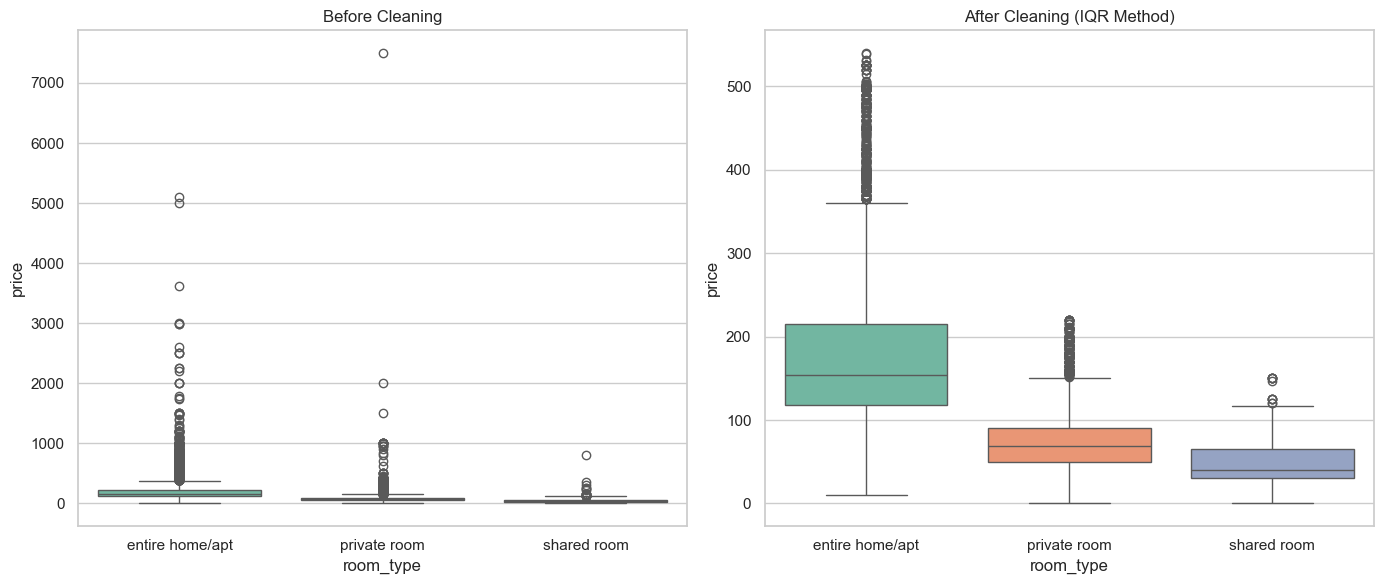

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(data=airbnb_merged, x='room_type', y='price', ax=axes[0], palette='Set2')
axes[0].set_title("Before Cleaning")
sns.boxplot(data=airbnb_clean, x='room_type', y='price', ax=axes[1], palette='Set2')
axes[1].set_title("After Cleaning (IQR Method)")
plt.tight_layout()
plt.show()

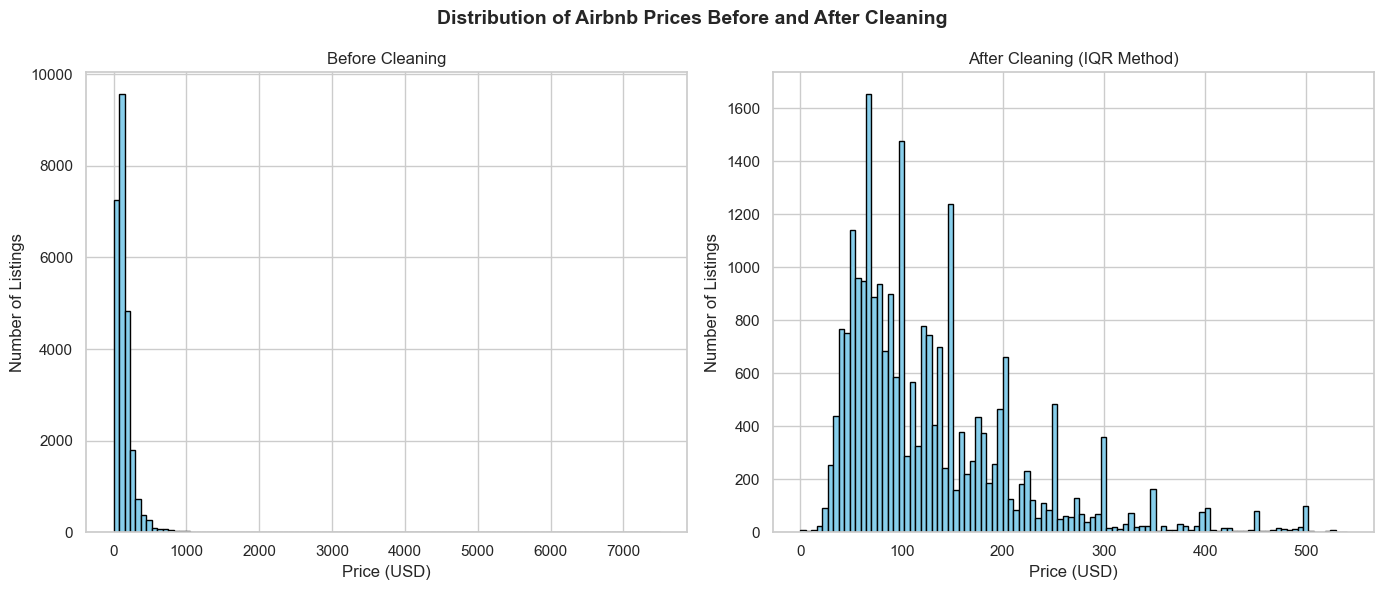

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram before cleaning
axes[0].hist(airbnb_merged['price'], bins=100, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Number of Listings")

# Histogram after cleaning
axes[1].hist(airbnb_clean['price'], bins=100, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning (IQR Method)")
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Number of Listings")

plt.suptitle("Distribution of Airbnb Prices Before and After Cleaning", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Univariate Analysis (Cleaned Data)
1. Review dates
2. Room type distribution

In [46]:
airbnb_clean['last_review'] = pd.to_datetime(airbnb_clean['last_review'], errors='coerce')
print("Earliest review:", airbnb_clean['last_review'].min().date())
print("Latest review:", airbnb_clean['last_review'].max().date())

Earliest review: 2019-01-01
Latest review: 2019-07-09


In [51]:
# Average price by room type
avg_price_by_type = airbnb_clean.groupby('room_type')['price'].mean().round(2)
print(avg_price_by_type)

room_type
entire home/apt    178.26
private room        75.83
shared room         49.97
Name: price, dtype: float64


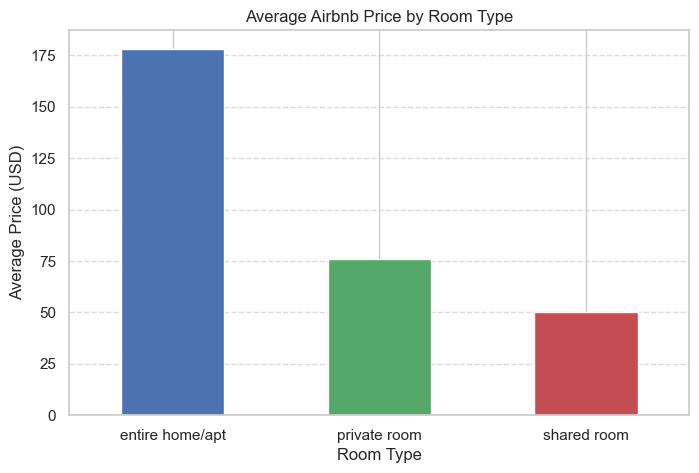

In [53]:
# room_counts = airbnb_clean['room_type'].value_counts()
# sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel')
# plt.title("Number of Listings by Room Type")
# plt.ylabel("Count")
# plt.show()


plt.figure(figsize=(8, 5))
avg_price_by_type.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Average Airbnb Price by Room Type')
plt.ylabel('Average Price (USD)')
plt.xlabel('Room Type')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Neighborhood Analysis

Question:

Which neighborhoods have the most listings or highest average prices?

Why it’s interesting:
Helps identify where the startup should focus investments or new listings.

In [54]:
avg_price_by_nbhood = airbnb_clean.groupby('nbhood_full')['price'].mean().sort_values(ascending=False).head(5)
print(avg_price_by_nbhood)

nbhood_full
Manhattan, Tribeca              283.673469
Manhattan, NoHo                 281.342105
Queens, Neponsit                274.666667
Manhattan, Flatiron District    261.741935
Staten Island, Willowbrook      249.000000
Name: price, dtype: float64


In [55]:
top_nbhood_full = airbnb_clean['nbhood_full'].value_counts().head(10)
print(top_nbhood_full)

nbhood_full
Brooklyn, Bedford-Stuyvesant    2196
Brooklyn, Williamsburg          1821
Manhattan, Harlem               1422
Brooklyn, Bushwick              1199
Manhattan, Hell's Kitchen       1080
Manhattan, East Village          844
Manhattan, Upper East Side       819
Manhattan, Upper West Side       744
Brooklyn, Crown Heights          744
Manhattan, East Harlem           664
Name: count, dtype: int64


In [56]:
# Extract borough (first part before the comma in nbhood_full)
airbnb_clean['borough'] = airbnb_clean['nbhood_full'].apply(lambda x: x.split(',')[0])
airbnb_clean['borough'].value_counts()

borough
Brooklyn         10339
Manhattan         9892
Queens            3442
Bronx              697
Staten Island      266
Name: count, dtype: int64

In [57]:
airbnb_clean.groupby('borough')['price'].mean().sort_values(ascending=False)

borough
Manhattan        161.452082
Brooklyn         114.876100
Queens            90.651365
Staten Island     85.484962
Bronx             78.279770
Name: price, dtype: float64

C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\888795778.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=airbnb_clean, x='borough', y='price', hue='room_type', ci=None, palette='Set2')


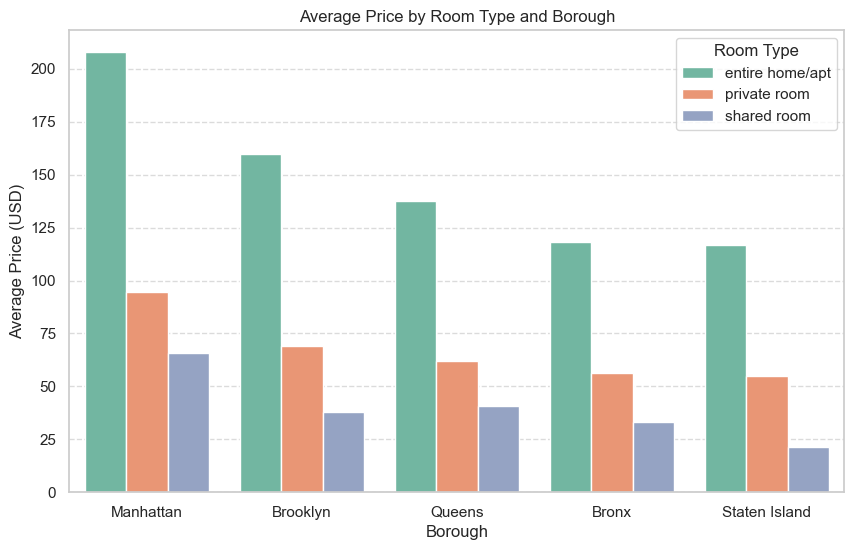

In [58]:
# Extract borough (first part before the comma in nbhood_full)
airbnb_clean['borough'] = airbnb_clean['nbhood_full'].apply(lambda x: x.split(',')[0])

plt.figure(figsize=(10,6))
sns.barplot(data=airbnb_clean, x='borough', y='price', hue='room_type', ci=None, palette='Set2')
plt.title('Average Price by Room Type and Borough')
plt.ylabel('Average Price (USD)')
plt.xlabel('Borough')
plt.legend(title='Room Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Host Behavior

Question:

Which hosts have the most listings?
Why it’s interesting:
Identifies professional landlords or potential partners.

In [59]:
top_hosts = airbnb_clean['host_name'].value_counts().head(10)
print(top_hosts)

host_name
Michael         210
Sonder (NYC)    201
David           190
John            172
Alex            149
Maria           121
Melissa         108
Anna            103
Daniel           99
Chris            92
Name: count, dtype: int64


C:\Users\pkuso\AppData\Local\Temp\ipykernel_21336\3505954026.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_host_prices.index, y=top_host_prices.values, palette='coolwarm')


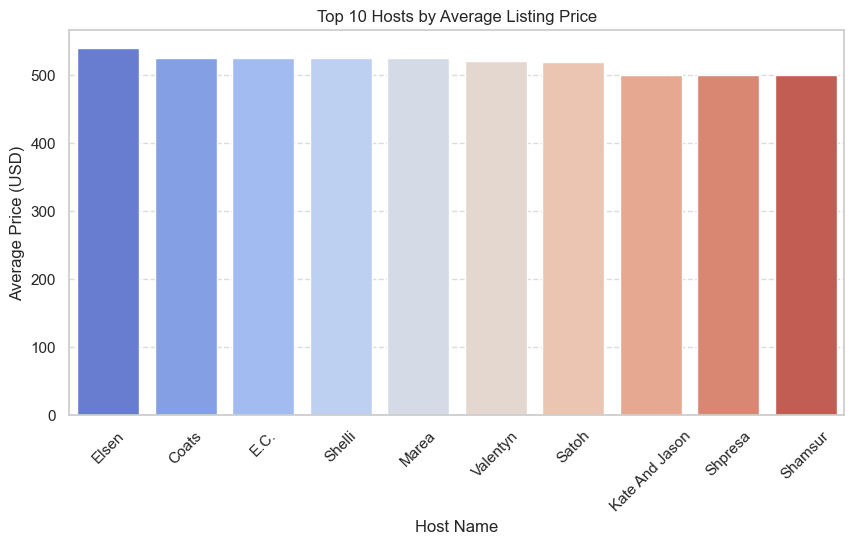

In [60]:
top_host_prices = (
    airbnb_clean.groupby('host_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_host_prices.index, y=top_host_prices.values, palette='coolwarm')
plt.title('Top 10 Hosts by Average Listing Price')
plt.ylabel('Average Price (USD)')
plt.xlabel('Host Name')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


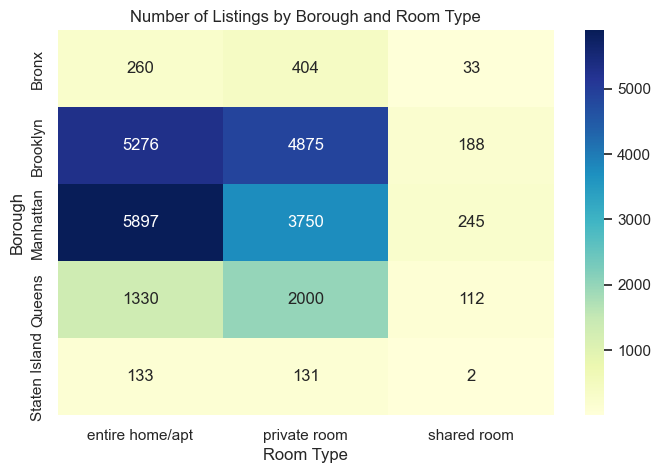

In [61]:
room_counts = pd.crosstab(airbnb_clean['borough'], airbnb_clean['room_type'])

plt.figure(figsize=(8,5))
sns.heatmap(room_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Number of Listings by Borough and Room Type')
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.show()
